In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
df = pd.read_csv("Advertising_And_sales.csv")

# Display the first five rows
df.head()


,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,12.8,58.4,12.9


In [4]:
df = pd.read_csv("Advertising_And_sales.csv")

# Remove unnecessary index column if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df.head()


,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,12.8,58.4,12.9


In [5]:
# Number of rows and columns
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData types:")
print(df.dtypes)


Dataset shape: (200, 5)

Columns:
Index(['ID', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

Data types:
ID             int64
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


In [6]:
df.isnull().sum()


ID           0
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [7]:
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


In [8]:
df.describe()


,ID,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.00000,200.000000,200.0000
mean,100.500000,147.032500,23.28950,30.554000,14.0380
std,57.879185,85.885186,14.86997,21.778621,5.2094
min,1.000000,0.700000,0.00000,0.300000,1.6000
25%,50.750000,74.375000,10.07500,12.750000,10.4000
50%,100.500000,149.750000,22.90000,25.750000,12.9000
75%,150.250000,218.825000,36.52500,45.100000,17.4000
max,200.000000,296.400000,49.60000,114.000000,27.0000


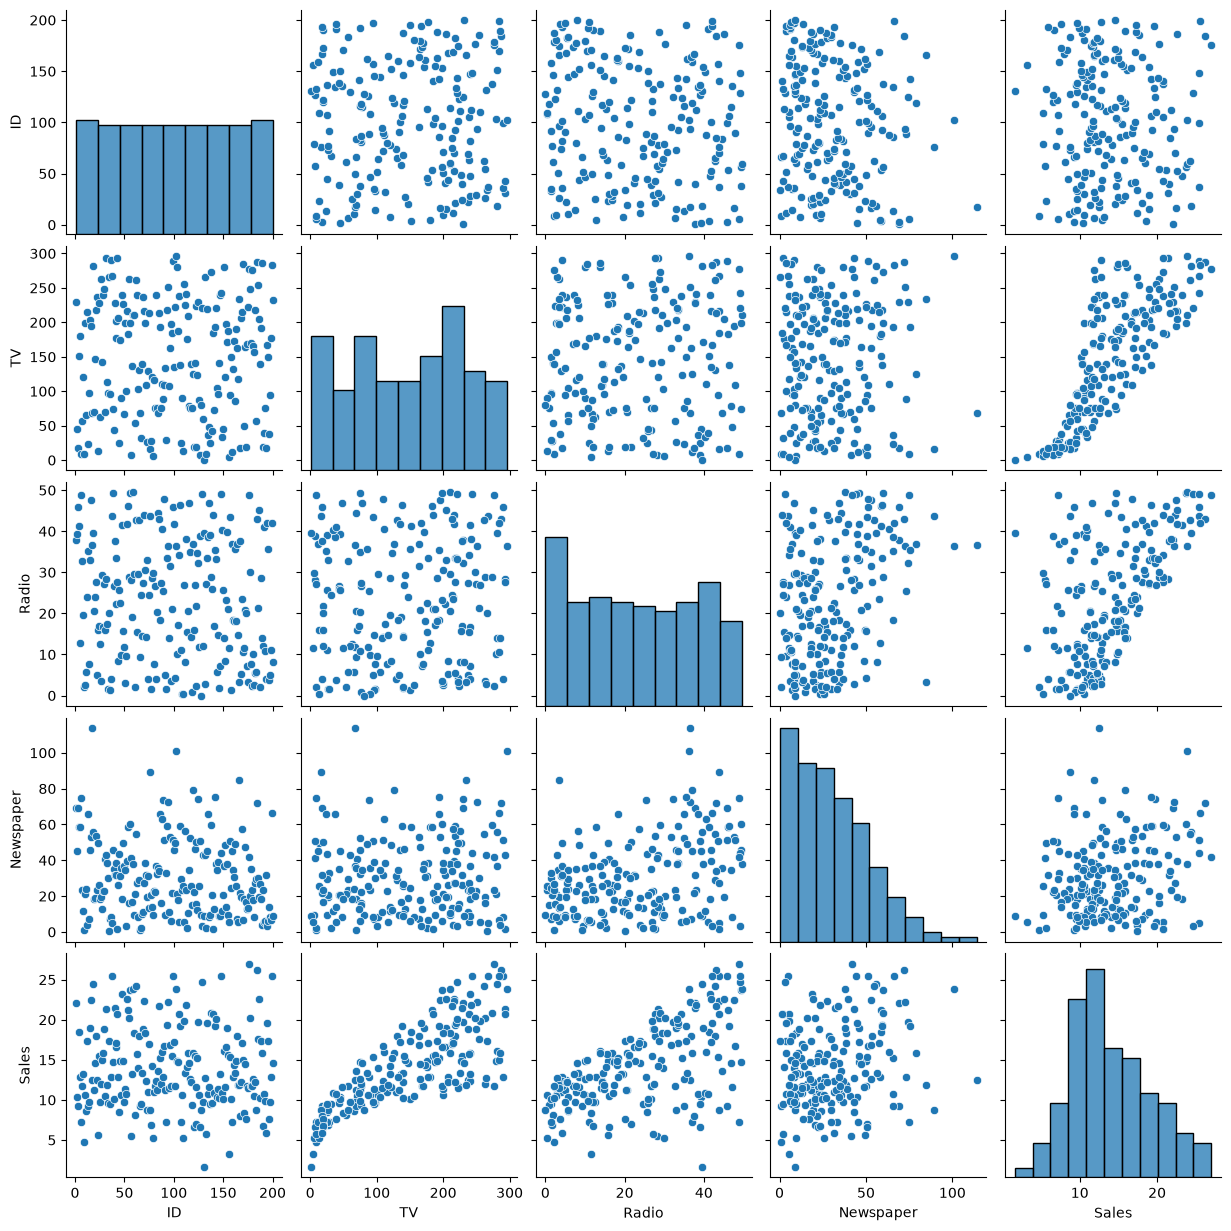

In [9]:
sns.pairplot(df)

plt.show()


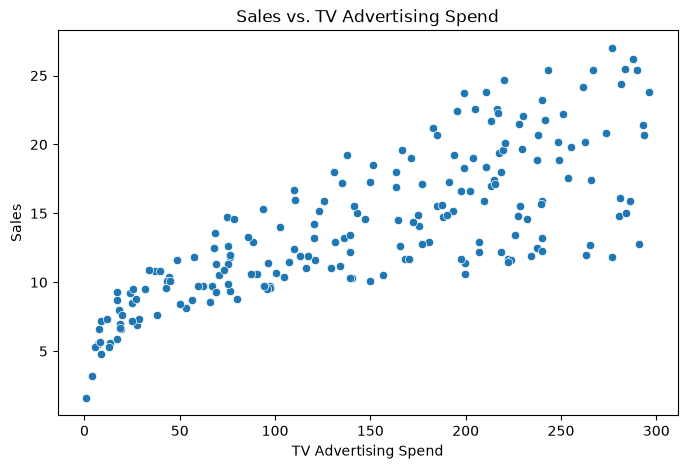

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("Sales vs. TV Advertising Spend")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()


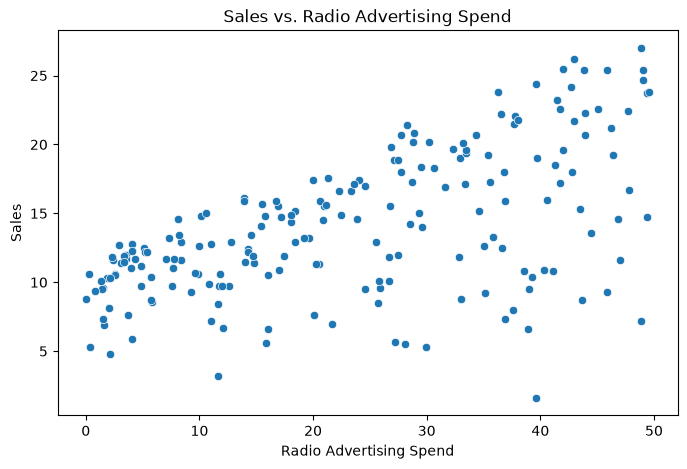

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Sales vs. Radio Advertising Spend")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.show()


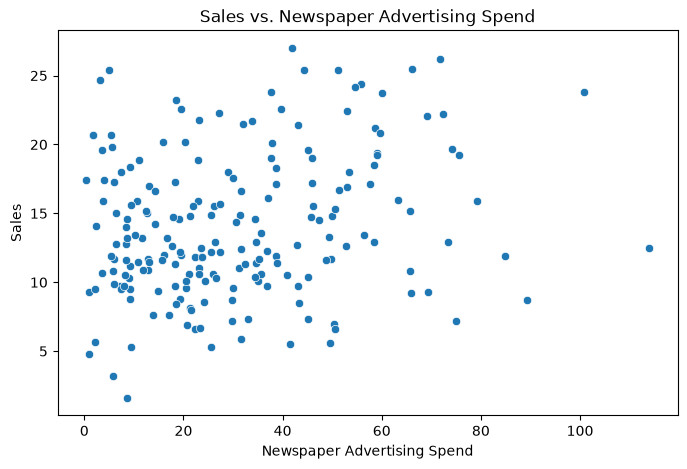

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Sales vs. Newspaper Advertising Spend")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.show()


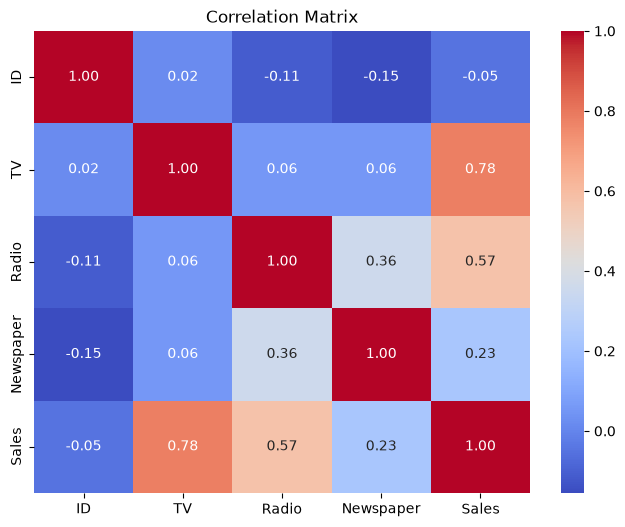

In [14]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


In [15]:
print(correlation["Sales"].sort_values(ascending=False))


Sales        1.000000
TV           0.783250
Radio        0.574929
Newspaper    0.226872
ID          -0.049469
Name: Sales, dtype: float64


In [16]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 160
Testing samples: 40


In [18]:
model = LinearRegression()

model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.19,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.059
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [19]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")


Intercept: 3.059075327195771

Coefficients:
TV: 0.0446
Radio: 0.1873
Newspaper: 0.0024


In [20]:
y_pred = model.predict(X_test)

# Display actual and predicted sales
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results.head(10)


,Actual Sales,Predicted Sales
0,16.9,16.395691
1,22.4,20.844402
2,21.4,21.538312
3,7.3,10.603545
4,24.7,22.078541
5,12.6,13.095539
6,22.3,21.025251
7,8.4,7.508424
8,11.5,13.654089
9,14.9,15.165667


In [21]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)


Mean Absolute Error: 1.45208191118176


In [22]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)


Mean Squared Error: 3.157334591646866


In [23]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)


Root Mean Squared Error: 1.7768890206332149


In [24]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)


R² Score: 0.899969103117516


In [25]:
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


MAE  : 1.4521
MSE  : 3.1573
RMSE : 1.7769
R²   : 0.9000


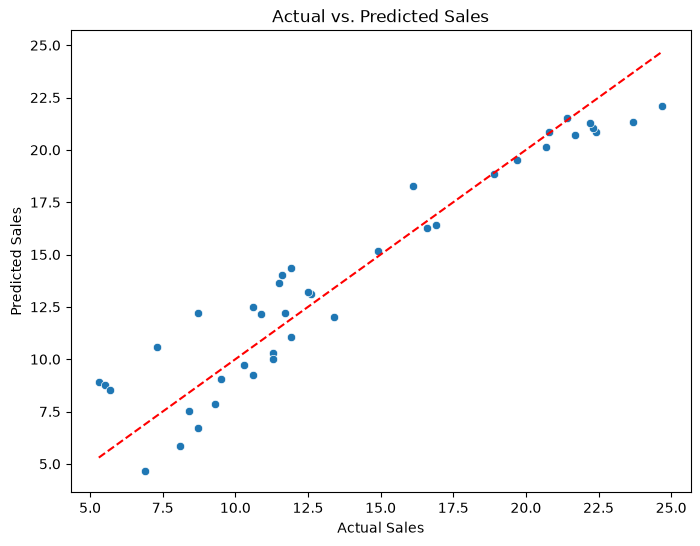

In [26]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()


In [27]:
new_advertising = pd.DataFrame({
    "TV": [150],
    "Radio": [30],
    "Newspaper": [20]
})

predicted_sales = model.predict(new_advertising)

print(f"Predicted Sales: {predicted_sales[0]:.2f}")


Predicted Sales: 15.42


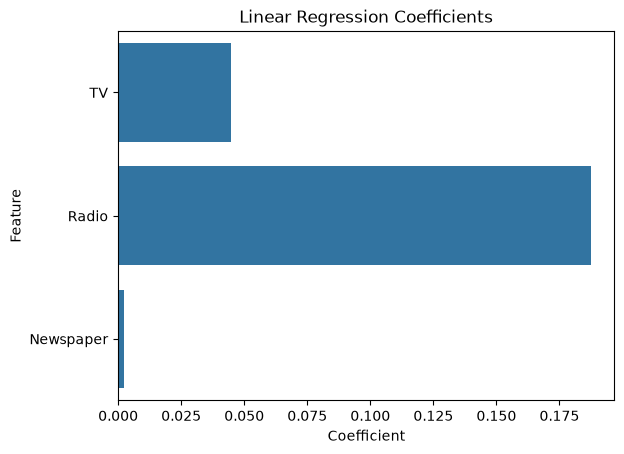

In [28]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")
plt.show()
